### https://www.kaggle.com/competitions/drawing-with-llms

In [3]:
import kagglehub
import pandas as pd
import re

In [4]:
# import json
# df_q = pd.read_parquet('./drawing-with-llms/questions.parquet')
# df_q = df_q.groupby("id").agg(
#     question=("question", lambda x: list(x)),  
#     choices=("choices", lambda x: [list(i) for i in x]),  
#     answer=("answer", lambda x: list(x))  
# ).reset_index()

In [ ]:
# # Initialize empty dictionary to hold the final format

# multiple_choice_qa = {
#     'question': [],
#     'choices': [],
#     'answer': []
# }

# mcq=[]
# # Iterate over the DataFrame and populate the dictionary
# for i, row in df_q.iterrows():
#     multiple_choice_qa['question']=row['question']
#     multiple_choice_qa['choices']=row['choices']  # Convert the string representation of a list back to a list
#     multiple_choice_qa['answer']=row['answer']
    
#     print(multiple_choice_qa)
#     #mcq.append([multiple_choice_qa]) 
#     #appending the json into list not working peoperly, may need to convert to string and work...
    

In [4]:
import openai
import pandas as pd
import time
import os
from dotenv import load_dotenv
load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")
deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

In [5]:
from openai import OpenAI
client = OpenAI(api_key=deepseek_api_key, base_url="https://api.deepseek.com")

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": "You are a helpful assistant"},
        {"role": "user", "content": "Hello are you"},
    ],
    stream=False
)

print(response.choices[0].message.content)

Hello! Yes, I'm here and ready to help. How can I assist you today? 😊


In [12]:
# Set up OpenAI client with your AP
#client = openai.OpenAI(api_key=openai_api_key)

# Function to get summary from OpenAI API
def get_topic():
    instruction_v0 = f"""
    I am participating SVG code generation competition. 
    
    The competition test data comprises of descriptions of everyday objects and scenes from a variety of domains. Your goal is to create a model that generates SVG depictions of these descriptions.
    The descriptions have the following properties:
    The descriptions are of common, generic subjects. No brand name or trademark or personal name occurs in any description. No people, even in generic form, occur in any description.
    The subjects described span about a dozen categories.  The remaining categories in the public and private sets are unique to each set. 
    No description has more than 200 characters. The average length is around 50 characters.   

   
    I am planing to generate syntetic data for my small LLM training. can you please give me 100 topics relavant to the competion above? 
    Each topic should have varying charater from 10 to 200 with 50 charater as average. Half of the topics should be from landscapes, abstract, and fashion.

    some examples are given below:
    <example>

    </example>
    Please give your respose in csv format. do not include charater length in response. only give response. 
    """

    instruction = f""" I am participating in an SVG code generation competition.
    
    The competition involves generating SVG images based on short textual descriptions of everyday objects and scenes, spanning a wide range of categories. The key guidelines are as follows:
    
    - Descriptions are generic and do not contain brand names, trademarks, or personal names.
    - No descriptions include people, even in generic terms.
    - Descriptions are concise—each is no more than 200 characters, with an average length of about 50 characters.
    - Categories cover various domains, with some overlap between public and private test sets.
    
    To train a small LLM model, I am preparing a synthetic dataset. Could you generate **500 unique topics** aligned with the competition style?
    
    **Requirements:**
    - Each topic should range between **20 and 200 characters**, with an **average around 60 characters**.
    - Ensure **diversity and creativity** across topics.
    - **50% of the topics** should come from the categories of **landscapes**, **abstract art**, and **fashion**.
    - Avoid duplication or overly similar phrasing.
    
    **Example topics:**
    <example>
    a purple forest at dusk, gray wool coat with a faux fur collar,  
    a lighthouse overlooking the ocean, burgundy corduroy pants with patch pockets and silver buttons,  
    orange corduroy overalls, a purple silk scarf with tassel trim,  
    a green lagoon under a cloudy sky, crimson rectangles forming a chaotic grid,  
    purple pyramids spiraling around a bronze cone, magenta trapezoids layered on a translucent silver sheet,  
    a snowy plain, black and white checkered pants,  
    a starlit night over snow-covered peaks, khaki triangles and azure crescents,  
    a maroon dodecahedron interwoven with teal threads.
    </example>
    
    Please return the 500 topics in csv format. Do not include category name, etc in the topic. Just give the topic.!
    """
    
    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "Generate a topic"},
                {"role": "user", "content": instruction}
            ],
            temperature=0.9,
            max_tokens=7200
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error: {e}")
        return None


In [5]:
# # Function to get summary from OpenAI API
# def get_svg_code(text):
#     instruction = f"""
#             Generate SVG code to visually represent the following text description, while respecting the given constraints.
#             <constraints>
#             * **Allowed Elements:** `svg`, `path`, `circle`, `rect`, `ellipse`, `line`, `polyline`, `polygon`, `g`, `linearGradient`, `radialGradient`, `stop`, `defs`
#             * **Allowed Attributes:** `viewBox`, `width`, `height`, `fill`, `stroke`, `stroke-width`, `d`, `cx`, `cy`, `r`, `x`, `y`, `rx`, `ry`, `x1`, `y1`, `x2`, `y2`, `points`, `transform`, `opacity`
#             </constraints>

#             Please ensure that the generated SVG code is well-formed, valid, and strictly adheres to these constraints. 
#             Focus on a clear and concise representation of the input description within the given limitations. 
#             Always give the complete SVG code with nothing omitted. Never use an ellipsis.

#             input description: {text}
#             """

#     try:
#         response = client.chat.completions.create(
#             model="deepseek-chat",
#             messages=[
#                 {"role": "system", "content": "Generate SVG code as per instruction"},
#                 {"role": "user", "content": instruction}
#             ],
#             temperature=0.5,
#             max_tokens=1024
#         )
#         return response.choices[0].message.content.strip()
    
#     except Exception as e:
#         print(f"Error: {e}")
#         return None

In [34]:
# # Function to get summary from OpenAI API
# from openai import OpenAI
# client = OpenAI(api_key=deepseek_api_key, base_url="https://api.deepseek.com")

# def get_vqa_for_topic(description):
    
#     description = description  # replace with your input
    
#     instruction = f"""
#     I am participating in an SVG code generation competition. I have trained a model to generate SVG code for a given topic. The generated code is converted into an image and evaluated using visual question answering (VQA) by an evaluation model. The questions and answers will be about the description of the generated code. 
    
#     Here is an example description and corresponding visual question answering (VQA) pair:
    
#     Example#1:
#     {{
#       'description': 'a purple forest at dusk',
#         'question': ['What is the main setting of the image?', 'Is there anything purple in the image?', 'What time of day is suggested in the image?', 'What color is prominently featured in the image?'],
#         'choices': [['beach', 'desert', 'forest', 'mountain'], ['no', 'yes'], ['dawn', 'dusk', 'midday', 'midnight'], ['green', 'orange', 'purple', 'white']],
#         'answer': ['forest', 'yes', 'dusk', 'purple']

#     }}
    
#     Example#2:
#     {{
#         'description': 'gray wool coat with a faux fur collar',
#         'question': ['What color is the coat?', 'What part of the coat has faux fur?', 'Is the coat purple?', 'What material is the coat made of?'],
#         'choices': [['blue', 'brown', 'gray', 'red'], ['collar', 'hem', 'pockets', 'sleeves'], ['no', 'yes'], ['cotton', 'leather', 'silk', 'wool']],
#         'answer': ['gray', 'collar', 'no', 'wool']
#     }}    
#     Now, generate a similar visual question answering pair for the following description:
#     '{description}'
#     """


#     try:
#         response = client.chat.completions.create(
#             model="deepseek-chat",
#             messages=[
#                 {"role": "system", "content": "You are a helpful assistant to generate visual question ansering pair"},
#                 {"role": "user", "content": instruction}
#             ],
#             temperature=0.6,
#             max_tokens=2048
#         )
#         return response.choices[0].message.content.strip()
    
#     except Exception as e:
#         print(f"Error: {e}")
#         return None

In [13]:
#generate random topic for svg training date
import csv
from io import StringIO
import re

topics_list=[]
  
for i in range(10):
    print(i)
    response = get_topic()
    topics_list.append(response)
    with open(f"topics_{i}.txt", "w") as file:
        file.write(response + "\n")  
    
#     # # Extracting topics using regex
#     # topics = re.findall(r'"(.*?)"', response)
#     # # Removing the header "Topic"
#     # topics = [t for t in topics if t.lower() != "topic"]
#     # topics_list.extend(topics)
    
#     # Read CSV and convert to a clean list
#     csv_file = StringIO(response)
#     reader = csv.reader(csv_file)
#     next(reader)  # Skip header
#     next(reader)  # Skip header
#     topics = [row[0] for row in reader]
#     topics_list.extend(topics)
   
# print(len(topics_list))

0
1
2
3
4
5
6
7
8
9


In [11]:
# # Writing to a text file
# topics_string = '\n'.join(topics_list)
# # Write to a text file
# with open("topics_train4.txt", "w") as file:
#     file.write(topics_string)

In [26]:
# import pandas as pd
# df1 = pd.read_table("topics_train3.txt", header=None)
# df1.columns = ["topic"]
# print(df1.shape)

# df2 = pd.read_table("topics_train4.txt", header=None)
# df2.columns = ["topic"]
# print(df2.shape)

# df=pd.concat([df1, df2], ignore_index=True)
# print(df.shape)

# df = df.sample(n=2000, random_state=42) 
# print(df.shape)

(846, 1)
(4785, 1)
(5631, 1)
(2000, 1)


In [27]:
df

,topic
3135,A wooden gate in a country lane
1835,A vintage typewriter with keys slightly worn
3832,A quiet vineyard with rows of grapevines
1919,A wooden barrel with metal hoops
4418,A smooth gradient of warm oranges
...,...
4463,A smooth gradient of deep forest greens
156,Abstract ink strokes resembling waves
3753,A bohemian-style maxi dress with fringe details
2404,A silk hair clip


In [35]:
from tqdm import tqdm
tqdm.pandas()
df=pd.read_csv('./drawing-with-llms/svg_score_test.csv',header=[0])
#df=df[['description','gptsvg']]
df["response"] = df["description"].progress_apply(get_vqa_for_topic)

100%|███████████████████████████████████████████| 76/76 [17:10<00:00, 13.56s/it]


In [36]:
df.to_csv('response_vqa.csv',index=False)

In [18]:
get_vqa_for_topic('golden sun in the east beach')

'Here is a visual question answering (VQA) pair for the description **\'golden sun in the east beach\'**:\n\n```json\n{\n  "description": "golden sun in the east beach",\n  "question": [\n    "Is the sun colored golden?",\n    "Is the beach located in the east?",\n    "Are there any blue elements in the image?",\n    "Is the sun setting or rising?"\n  ],\n  "choices": [\n    ["no", "yes"],\n    ["no", "yes"],\n    ["no", "yes"],\n    ["setting", "rising"]\n  ],\n  "answer": ["yes", "yes", "yes", "rising"]\n}\n```\n\n### Explanation:\n1. **"Is the sun colored golden?"** – Checks if the primary color of the sun matches the description (golden).  \n2. **"Is the beach located in the east?"** – Confirms the positional detail mentioned ("east beach").  \n3. **"Are there any blue elements in the image?"** – Likely referring to the sky or ocean in a beach scene.  \n4. **"Is the sun setting or rising?"** – Since it\'s in the east, the sun is rising (implied by "east").  \n\nLet me know if you\'

In [30]:
import re
def clean_svg(text):
    svg_code = re.search(r'```xml\n(.*?)\n```', text, re.DOTALL)
    
    if svg_code:
        extracted_svg = svg_code.group(1)
        return extracted_svg
    else:
        return '<svg </svg>'

In [31]:
df["svg_code"] = df["response"].progress_apply(clean_svg)

100%|███████████████████████████████████| 2000/2000 [00:00<00:00, 136066.05it/s]


In [32]:
df['svg_code'].iloc[0]

'<svg viewBox="0 0 200 150" width="400" height="300" xmlns="http://www.w3.org/2000/svg">\n  <defs>\n    <linearGradient id="wood" x1="0%" y1="0%" x2="100%" y2="0%">\n      <stop offset="0%" stop-color="#8B4513" />\n      <stop offset="50%" stop-color="#A0522D" />\n      <stop offset="100%" stop-color="#8B4513" />\n    </linearGradient>\n    <linearGradient id="ground" x1="0%" y1="0%" x2="0%" y2="100%">\n      <stop offset="0%" stop-color="#228B22" />\n      <stop offset="100%" stop-color="#556B2F" />\n    </linearGradient>\n  </defs>\n\n  <!-- Background -->\n  <rect x="0" y="0" width="200" height="150" fill="skyblue" />\n  <rect x="0" y="100" width="200" height="50" fill="url(#ground)" />\n\n  <!-- Country lane path -->\n  <path d="M0 120 Q100 80 200 120" fill="none" stroke="#D2B48C" stroke-width="15" />\n\n  <!-- Wooden gate -->\n  <g transform="translate(80, 70)">\n    <!-- Gate posts -->\n    <rect x="-5" y="0" width="10" height="60" fill="url(#wood)" />\n    <rect x="45" y="0" wid

In [ ]:
# # We can play with our Model and render its SVG output (don't export!)
# from IPython.display import SVG, display
# for svg in df["svg_code"].iloc[:10]:
#     #print(svg)
#     display(SVG(svg))

In [34]:
from transformers import AutoProcessor, AutoModel
model = AutoModel.from_pretrained("google/siglip-so400m-patch14-384")
processor = AutoProcessor.from_pretrained("google/siglip-so400m-patch14-384")

In [ ]:
import torch
from PIL import Image
import cairosvg
import os

def svgMetric(prompt, svg):
    try:
        # Convert SVG to PNG
        cairosvg.svg2png(svg, write_to="./tmp/temp.png")
        
        # Open and process the image
        image = Image.open('./tmp/temp.png').convert("RGB")
        texts = ["SVG illustration of " + prompt]
        inputs = processor(text=texts, images=image, padding="max_length", return_tensors="pt")
        
        # Inference without gradient tracking
        with torch.no_grad():
            outputs = model(**inputs)
        
        logits_per_image = outputs.logits_per_image
        probs = torch.sigmoid(logits_per_image)
        
        # Clean up temporary PNG file
        #os.remove('./tmp/temp.png')
        
        return probs[0][0].item()

    
    except Exception as e:
        print(f"An error occurred: {e}")
        return None




In [ ]:
# Using apply to process each row in the DataFrame
df['score'] = df.progress_apply(lambda row: svgMetric(row['topic'], row['svg_code']), axis=1)


In [37]:
# Display results
print('mean gpt-4o score:',df['score'].mean())

mean gpt-4o score: 0.57221991802494


In [38]:
df.to_csv('svg_score_train3.csv',index=False)

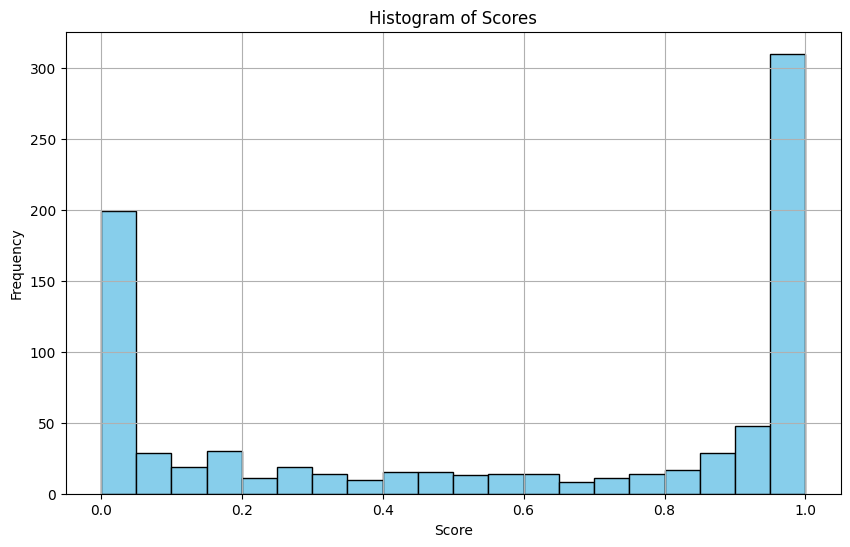

In [39]:
import matplotlib.pyplot as plt

# Plot histogram of the 'score' column
plt.figure(figsize=(10, 6))
plt.hist(df['score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [40]:
count = (df['score'] > 0.6).sum()
print(f"Number of entries with score > 0.6: {count}")

Number of entries with score > 0.6: 451


In [23]:
df['response'].iloc[1]

'Here is a visual question answering (VQA) pair for the description \'Morning dew on grass\':\n\n```json\n{\n  "description": "Morning dew on grass",\n  "question": [\n    "Is the grass green in color?",\n    "Are there water droplets visible on the grass?",\n    "Is the background of the image blue?",\n    "Are there any flowers present in the image?"\n  ],\n  "choices": [["no", "yes"], ["no", "yes"], ["no", "yes"], ["no", "yes"]],\n  "answer": ["yes", "yes", "no", "no"]\n}\n```\n\n### Explanation:\n- **"Is the grass green in color?"**: Morning dew typically implies fresh grass, which is usually green. Hence, the answer is "yes."\n- **"Are there water droplets visible on the grass?"**: The description mentions "morning dew," which implies water droplets. Hence, the answer is "yes."\n- **"Is the background of the image blue?"**: The description does not mention the sky or any background, so the answer is "no."\n- **"Are there any flowers present in the image?"**: The description does n